**Data exploration:** loads the cleaned OpenAlex corpus and checks the shape/structure of the key columns (language, keyword-matching fields, publication year range) before building the keyword-network and sentiment analysis.

In [3]:
import pandas as pd

df = pd.read_parquet('../final_openalex_pipeline/data/processed/openalex_clean_corpus.parquet')

print("--- language value counts ---")
print(df['language'].value_counts(dropna=False).head(10))
print()
print("--- sample retrieved_by_term(s) ---")
print(df[['retrieved_by_term', 'retrieved_by_terms', 'detected_terms_in_title_abstract']].head(5).to_string())
print()
print("--- dtypes of those columns ---")
print(df[['retrieved_by_term', 'retrieved_by_terms', 'detected_terms_in_title_abstract', 'search_years']].dtypes)
print()
print("--- publication_year range ---")
print(df['publication_year'].min(), '-', df['publication_year'].max())

--- language value counts ---
language
en     60000
NaN     7091
es      1272
pt      1021
id       863
de       677
fr       386
ru       201
ar       143
it       113
Name: count, dtype: int64

--- sample retrieved_by_term(s) ---
  retrieved_by_term                           retrieved_by_terms detected_terms_in_title_abstract
0     dialog system                                dialog system                    dialog system
1     dialog system                                dialog system                    dialog system
2   dialogue system                              dialogue system                  dialogue system
3   dialogue system  dialogue system; natural language interface       natural language interface
4   dialogue system                              dialogue system                  dialogue system

--- dtypes of those columns ---
retrieved_by_term                   str
retrieved_by_terms                  str
detected_terms_in_title_abstract    str
search_years               

**Keyword vocabulary:** parses the semicolon-separated detected-terms column into a list per record, then counts how often each Search B keyword actually appears across the corpus.

In [4]:
df['detected_terms_list'] = df['detected_terms_in_title_abstract'].fillna('').apply(
    lambda s: [t.strip() for t in s.split(';') if t.strip()]
)

from collections import Counter

term_counts = Counter(term for terms in df['detected_terms_list'] for term in terms)
term_freq = pd.Series(term_counts).sort_values(ascending=False)

print(f"Total distinct keyword terms detected: {len(term_freq)}")
term_freq

Total distinct keyword terms detected: 11


chatbot                          42669
dialogue system                   9204
conversational agent              8062
virtual assistant                 5785
voice assistant                   4232
conversational AI                 3463
dialog system                     3188
natural language interface        2611
spoken dialogue system            2119
embodied conversational agent     1339
chatterbot                         364
dtype: int64

**Keyword frequency over time:** explodes the per-record keyword list against publication year to build a year-by-keyword count table, showing how each term's usage has risen or fallen.

In [5]:
term_year = df.explode('detected_terms_list').dropna(subset=['detected_terms_list'])
term_year_counts = term_year.groupby(['publication_year', 'detected_terms_list']).size().unstack(fill_value=0)

term_year_counts.tail(20)

detected_terms_list,chatbot,chatterbot,conversational AI,conversational agent,dialog system,dialogue system,embodied conversational agent,natural language interface,spoken dialogue system,virtual assistant,voice assistant
publication_year,,,,,,,,,,,
2006,11,11,0,76,117,228,48,48,95,12,0
2007,24,9,0,99,87,204,54,57,80,9,0
2008,27,12,1,110,119,196,64,38,80,12,0
2009,25,20,2,98,105,215,56,63,100,9,0
2010,36,25,3,125,110,236,55,55,106,7,1
2011,26,24,0,162,85,220,67,40,87,17,1
2012,34,17,0,123,85,225,54,54,103,13,2
2013,49,12,0,135,93,167,60,30,62,17,5
2014,54,8,0,131,86,208,44,54,80,19,6


**Keyword frequency over time (chart):** small-multiples line chart, one panel per keyword sorted by total volume, showing each term's individual rise/decline shape across 1976–2025.

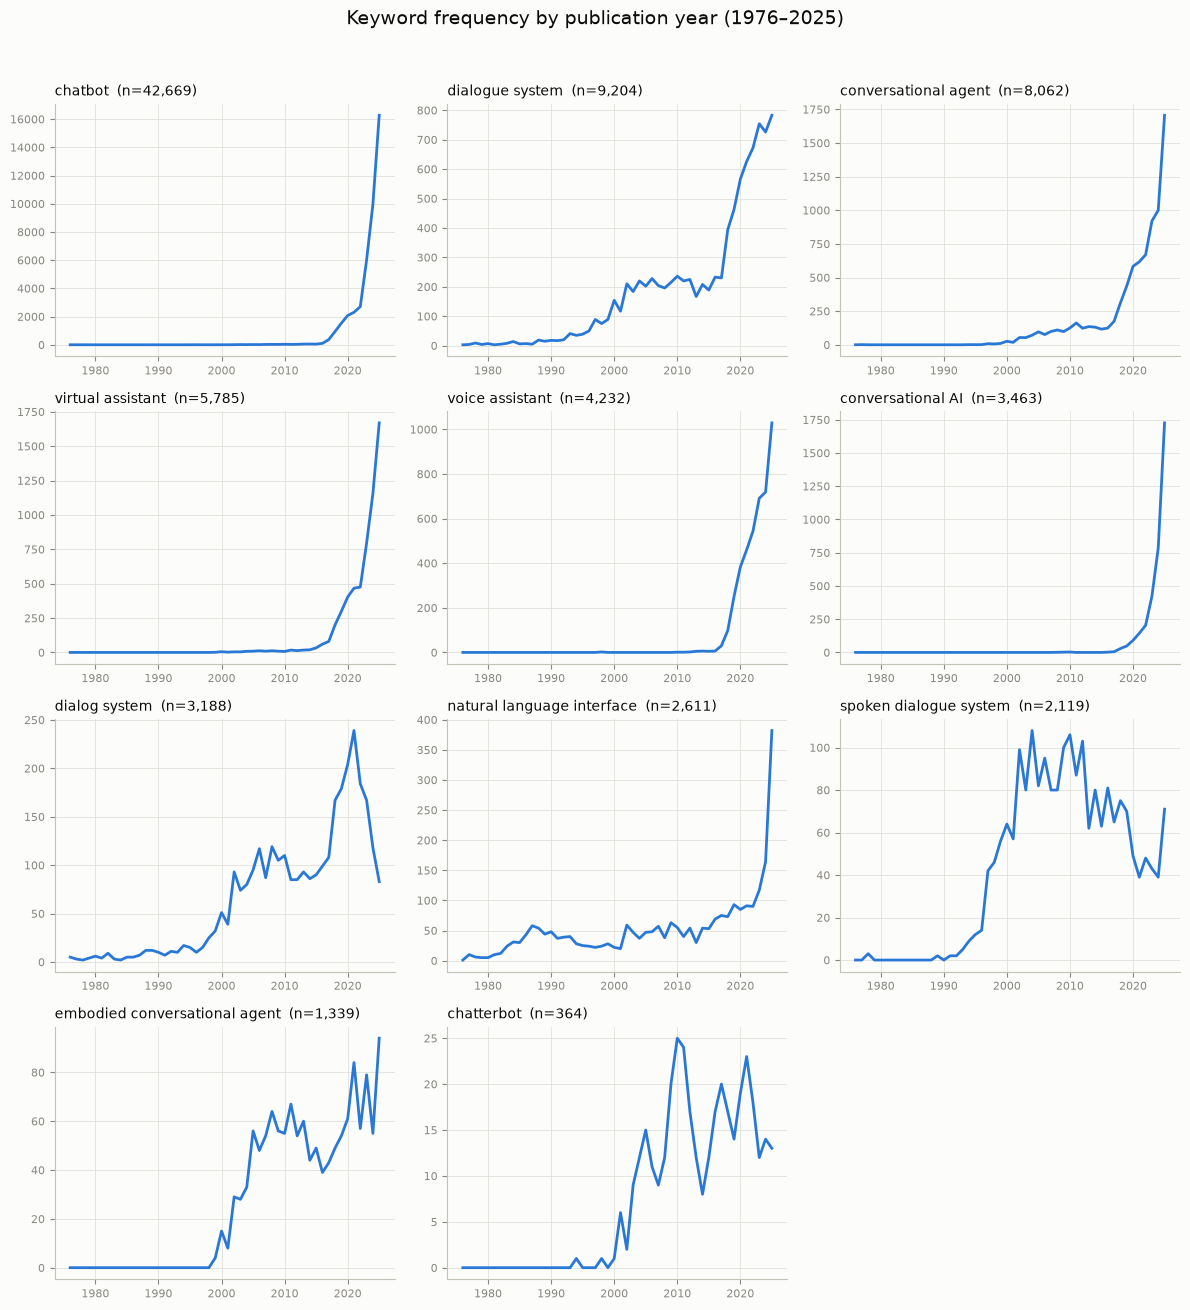

In [6]:
import matplotlib.pyplot as plt

PRIMARY_INK = "#0b0b0b"
MUTED_INK = "#898781"
GRIDLINE = "#e1e0d9"
BASELINE = "#c3c2b7"
CHART_SURFACE = "#fcfcfb"
LINE_HUE = "#2a78d6"

term_order = term_freq.index.tolist()  # already sorted by total frequency, descending

n_terms = len(term_order)
n_cols = 3
n_rows = -(-n_terms // n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 3.2 * n_rows), facecolor=CHART_SURFACE)
axes = axes.flatten()

for i, term in enumerate(term_order):
    ax = axes[i]
    ax.set_facecolor(CHART_SURFACE)
    series = term_year_counts[term]
    ax.plot(series.index, series.values, color=LINE_HUE, linewidth=2)
    ax.set_title(f"{term}  (n={term_freq[term]:,})", fontsize=10, color=PRIMARY_INK, loc="left")
    ax.tick_params(colors=MUTED_INK, labelsize=8)
    ax.grid(True, color=GRIDLINE, linewidth=0.6)
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)
    for spine in ["left", "bottom"]:
        ax.spines[spine].set_color(BASELINE)

for j in range(n_terms, len(axes)):
    fig.delaxes(axes[j])

fig.suptitle("Keyword frequency by publication year (1976–2025)", fontsize=14, color=PRIMARY_INK, y=1.02)
fig.tight_layout()
fig.savefig("keyword_frequency_small_multiples.png", dpi=200, bbox_inches="tight", facecolor=CHART_SURFACE)
plt.show()

**Restrict to English:** sentiment models are English-tuned, so from here on we work on a subset with a real, English abstract. Keyword frequency/network above intentionally used the full corpus; sentiment does not.

In [7]:
df_en = df[(df["language"] == "en") & (df["has_abstract"] == True)].copy()
print(f"Rows before language filter: {len(df)}")
print(f"Rows with English abstract: {len(df_en)}")

Rows before language filter: 72843
Rows with English abstract: 52448


**Sentiment scoring:** runs VADER (rule-based sentiment tuned for short text) over every English abstract, producing a compound score from -1 (very negative) to +1 (very positive).

In [8]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

analyzer = SentimentIntensityAnalyzer()

def score_sentiment(text):
    if not isinstance(text, str) or not text.strip():
        return None
    return analyzer.polarity_scores(text)["compound"]

df_en["sentiment_compound"] = df_en["abstract"].apply(score_sentiment)

def label_sentiment(score):
    if score is None:
        return None
    if score >= 0.05:
        return "positive"
    if score <= -0.05:
        return "negative"
    return "neutral"

df_en["sentiment_label"] = df_en["sentiment_compound"].apply(label_sentiment)

print(df_en["sentiment_label"].value_counts())
print(f"Mean compound sentiment: {df_en['sentiment_compound'].mean():.3f}")

sentiment_label
positive    47098
negative     3746
neutral      1604
Name: count, dtype: int64
Mean compound sentiment: 0.724


**Sentiment by keyword:** explodes each abstract's detected keywords, then computes the average sentiment associated with each term across the whole corpus — answers "what's the sentiment surrounding each keyword."

In [9]:
term_sentiment = (
    df_en.explode("detected_terms_list")
    .dropna(subset=["detected_terms_list"])
    .groupby("detected_terms_list")["sentiment_compound"]
    .agg(["mean", "median", "count"])
    .sort_values("mean", ascending=False)
)
term_sentiment

,mean,median,count
detected_terms_list,,,
virtual assistant,0.820621,0.95240,4598
natural language interface,0.790673,0.91000,2104
conversational AI,0.790283,0.94370,2598
chatbot,0.754197,0.94220,28804
conversational agent,0.718340,0.91045,6352
voice assistant,0.712810,0.92170,3386
chatterbot,0.686831,0.86250,195
embodied conversational agent,0.656379,0.86690,1070
dialogue system,0.621781,0.81760,7497


**Chart:** mean sentiment per keyword, ranked — a magnitude comparison across categories, so single-hue sequential bars (not categorical colors) per the chart-form guide.

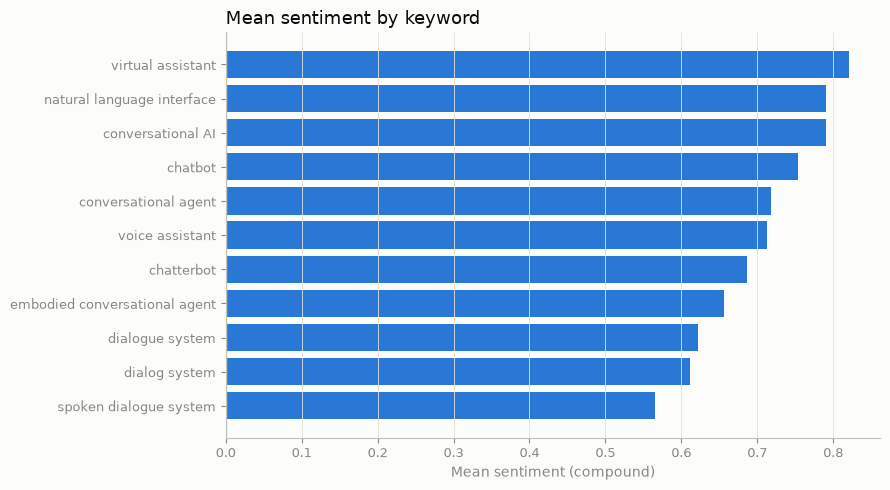

In [10]:
fig, ax = plt.subplots(figsize=(9, 5), facecolor=CHART_SURFACE)
ax.set_facecolor(CHART_SURFACE)

bars = term_sentiment.sort_values("mean")
ax.barh(bars.index, bars["mean"], color=LINE_HUE)
ax.axvline(0, color=BASELINE, linewidth=1)
ax.set_xlabel("Mean sentiment (compound)", color=MUTED_INK)
ax.tick_params(colors=MUTED_INK, labelsize=9)
ax.set_title("Mean sentiment by keyword", fontsize=13, color=PRIMARY_INK, loc="left")
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
for spine in ["left", "bottom"]:
    ax.spines[spine].set_color(BASELINE)
ax.grid(True, axis="x", color=GRIDLINE, linewidth=0.6)

fig.tight_layout()
fig.savefig("sentiment_by_keyword.png", dpi=200, bbox_inches="tight", facecolor=CHART_SURFACE)
plt.show()

**Sentiment over time:** same small-multiples layout as the frequency chart, but tracking mean sentiment per keyword per year instead of volume — deliberately a separate chart rather than a second y-axis, so frequency and sentiment stay independently readable.

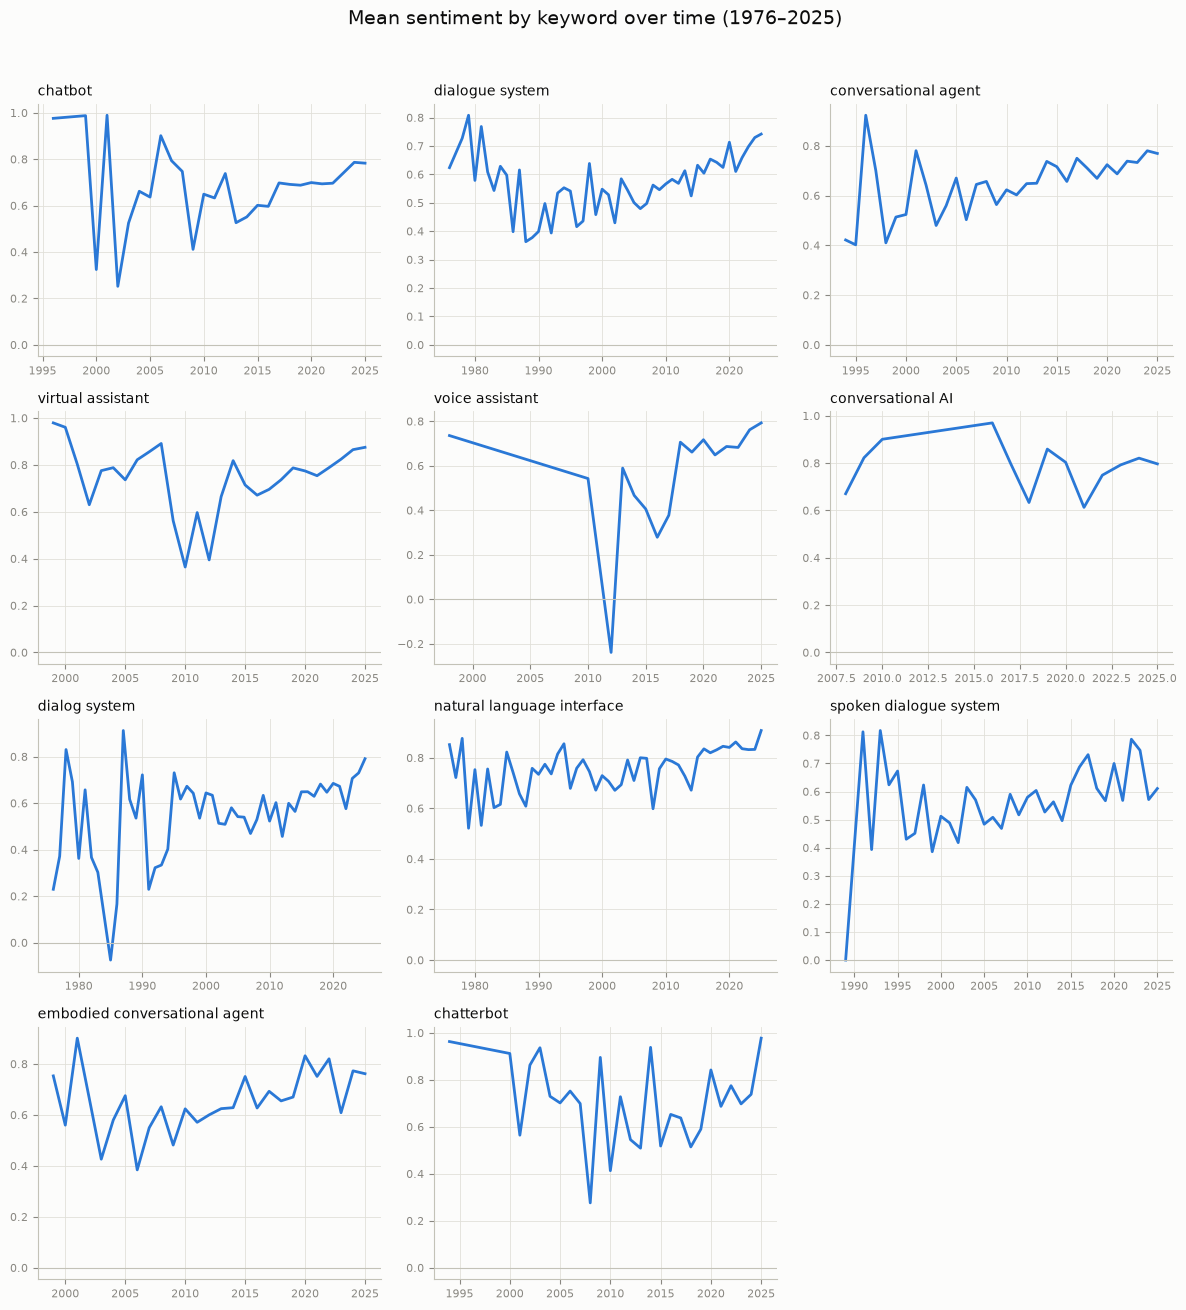

In [11]:
term_year_sentiment = (
    df_en.explode("detected_terms_list")
    .dropna(subset=["detected_terms_list"])
    .groupby(["publication_year", "detected_terms_list"])["sentiment_compound"]
    .mean()
    .unstack()
)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 3.2 * n_rows), facecolor=CHART_SURFACE)
axes = axes.flatten()

for i, term in enumerate(term_order):
    ax = axes[i]
    ax.set_facecolor(CHART_SURFACE)
    if term in term_year_sentiment.columns:
        series = term_year_sentiment[term].dropna()
        ax.plot(series.index, series.values, color=LINE_HUE, linewidth=2)
    ax.axhline(0, color=BASELINE, linewidth=0.8)
    ax.set_title(term, fontsize=10, color=PRIMARY_INK, loc="left")
    ax.tick_params(colors=MUTED_INK, labelsize=8)
    ax.grid(True, color=GRIDLINE, linewidth=0.6)
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)
    for spine in ["left", "bottom"]:
        ax.spines[spine].set_color(BASELINE)

for j in range(n_terms, len(axes)):
    fig.delaxes(axes[j])

fig.suptitle("Mean sentiment by keyword over time (1976–2025)", fontsize=14, color=PRIMARY_INK, y=1.02)
fig.tight_layout()
fig.savefig("sentiment_over_time_small_multiples.png", dpi=200, bbox_inches="tight", facecolor=CHART_SURFACE)
plt.show()

**Popular vs. not-popular sentiment:** for each keyword, splits its years into "high-frequency" (above that keyword's own median yearly count) vs "low-frequency," then compares the sentiment distribution between the two — directly answers "sentiment when popular vs when not."

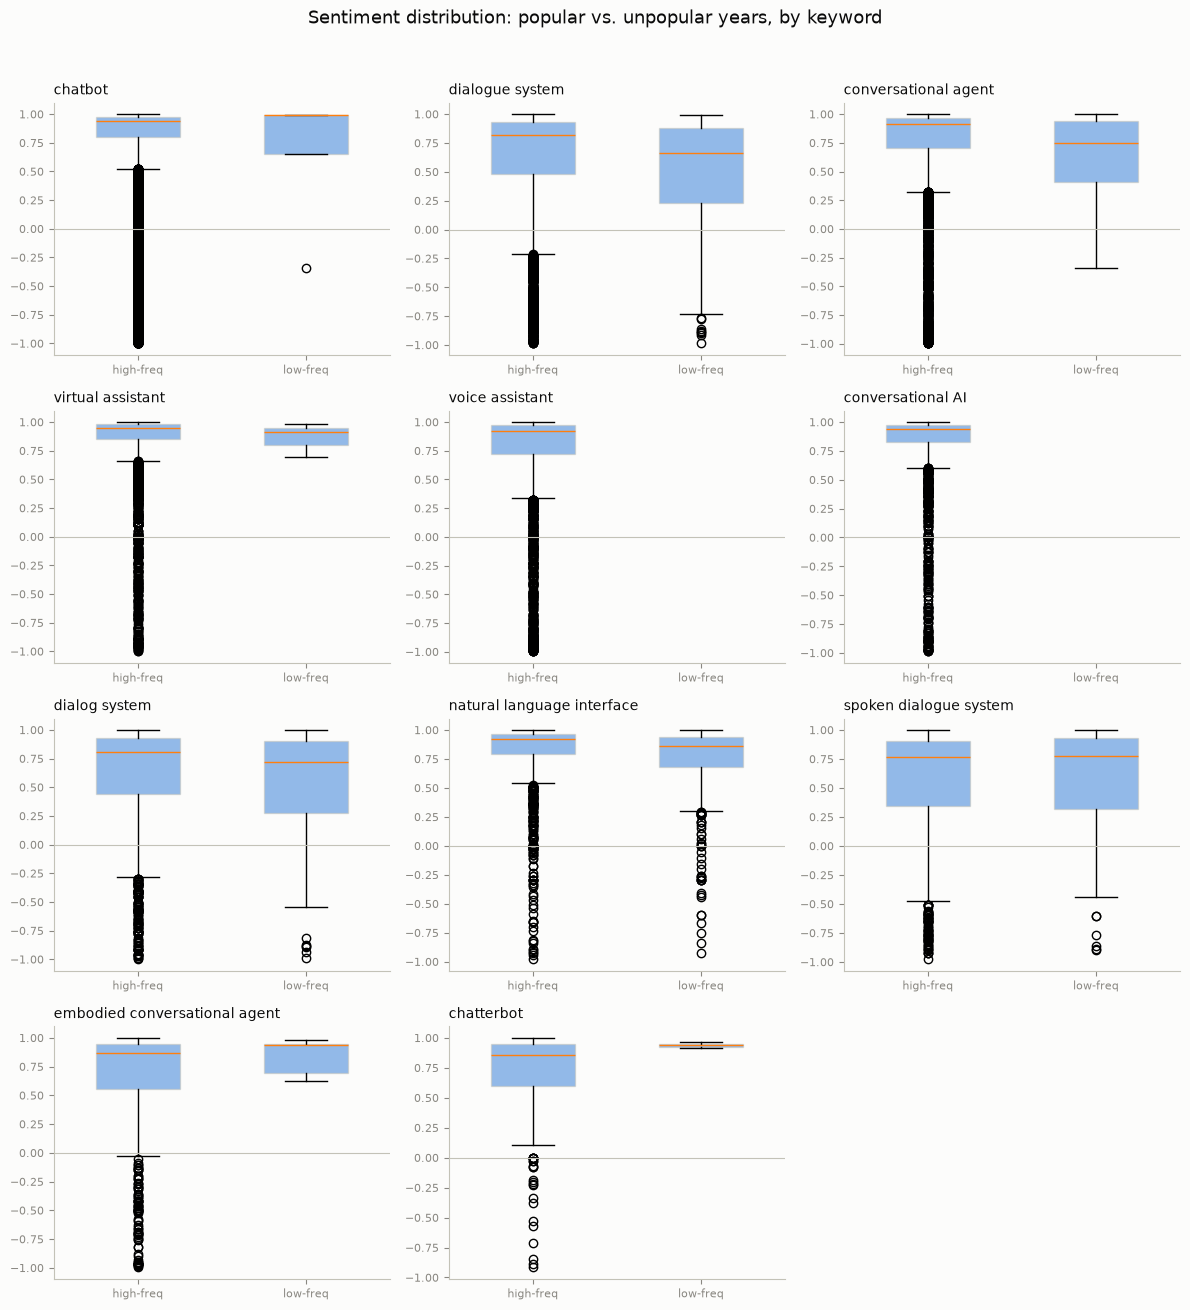

In [12]:
exploded = df_en.explode("detected_terms_list").dropna(subset=["detected_terms_list"]).copy()
exploded = exploded.rename(columns={"detected_terms_list": "term"})

year_counts_per_term = term_year_counts.stack().rename("year_count").reset_index()
year_counts_per_term.columns = ["publication_year", "term", "year_count"]

median_per_term = year_counts_per_term.groupby("term")["year_count"].transform("median")
year_counts_per_term["popularity"] = (
    year_counts_per_term["year_count"] >= median_per_term
).map({True: "high-frequency years", False: "low-frequency years"})

exploded = exploded.merge(
    year_counts_per_term[["publication_year", "term", "popularity"]],
    on=["publication_year", "term"],
    how="left",
)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 3.2 * n_rows), facecolor=CHART_SURFACE)
axes = axes.flatten()

for i, term in enumerate(term_order):
    ax = axes[i]
    ax.set_facecolor(CHART_SURFACE)
    subset = exploded[exploded["term"] == term]
    groups = [
        subset[subset["popularity"] == "high-frequency years"]["sentiment_compound"].dropna(),
        subset[subset["popularity"] == "low-frequency years"]["sentiment_compound"].dropna(),
    ]
    bp = ax.boxplot(groups, tick_labels=["high-freq", "low-freq"], patch_artist=True, widths=0.5)
    for patch in bp["boxes"]:
        patch.set_facecolor(LINE_HUE)
        patch.set_alpha(0.5)
        patch.set_edgecolor(BASELINE)
    ax.axhline(0, color=BASELINE, linewidth=0.8)
    ax.set_title(term, fontsize=10, color=PRIMARY_INK, loc="left")
    ax.tick_params(colors=MUTED_INK, labelsize=8)
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)
    for spine in ["left", "bottom"]:
        ax.spines[spine].set_color(BASELINE)

for j in range(n_terms, len(axes)):
    fig.delaxes(axes[j])

fig.suptitle("Sentiment distribution: popular vs. unpopular years, by keyword", fontsize=13, color=PRIMARY_INK, y=1.02)
fig.tight_layout()
fig.savefig("sentiment_popular_vs_not.png", dpi=200, bbox_inches="tight", facecolor=CHART_SURFACE)
plt.show()

**Keyword co-occurrence network setup:** builds a network per time period — nodes are keywords, an edge connects two keywords that appear together in the same abstract, edge weight = how often they co-occur. This is the direct visual answer to "how has the keyword network shifted."

In [13]:
import itertools
import networkx as nx

periods = [
    (1976, 1995, "1976–1995"),
    (1996, 2005, "1996–2005"),
    (2006, 2015, "2006–2015"),
    (2016, 2020, "2016–2020"),
    (2021, 2025, "2021–2025"),
]

def build_cooccurrence(term_lists):
    node_counts = Counter()
    edge_counts = Counter()
    for terms in term_lists:
        unique_terms = set(terms)
        node_counts.update(unique_terms)
        for a, b in itertools.combinations(sorted(unique_terms), 2):
            edge_counts[(a, b)] += 1
    return node_counts, edge_counts

period_graphs = {}
for start, end, label in periods:
    subset = df[(df["publication_year"] >= start) & (df["publication_year"] <= end)]
    node_counts, edge_counts = build_cooccurrence(subset["detected_terms_list"])
    G = nx.Graph()
    for term, count in node_counts.items():
        G.add_node(term, weight=count)
    for (a, b), weight in edge_counts.items():
        G.add_edge(a, b, weight=weight)
    period_graphs[label] = G
    print(f"{label}: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")

1976–1995: 7 nodes, 6 edges
1996–2005: 10 nodes, 19 edges
2006–2015: 11 nodes, 32 edges
2016–2020: 11 nodes, 49 edges
2021–2025: 11 nodes, 50 edges


**Network chart:** one panel per time period (small multiples), node size = keyword volume in that period, edge thickness = co-occurrence strength, fixed layout seed so panels are visually comparable across time.

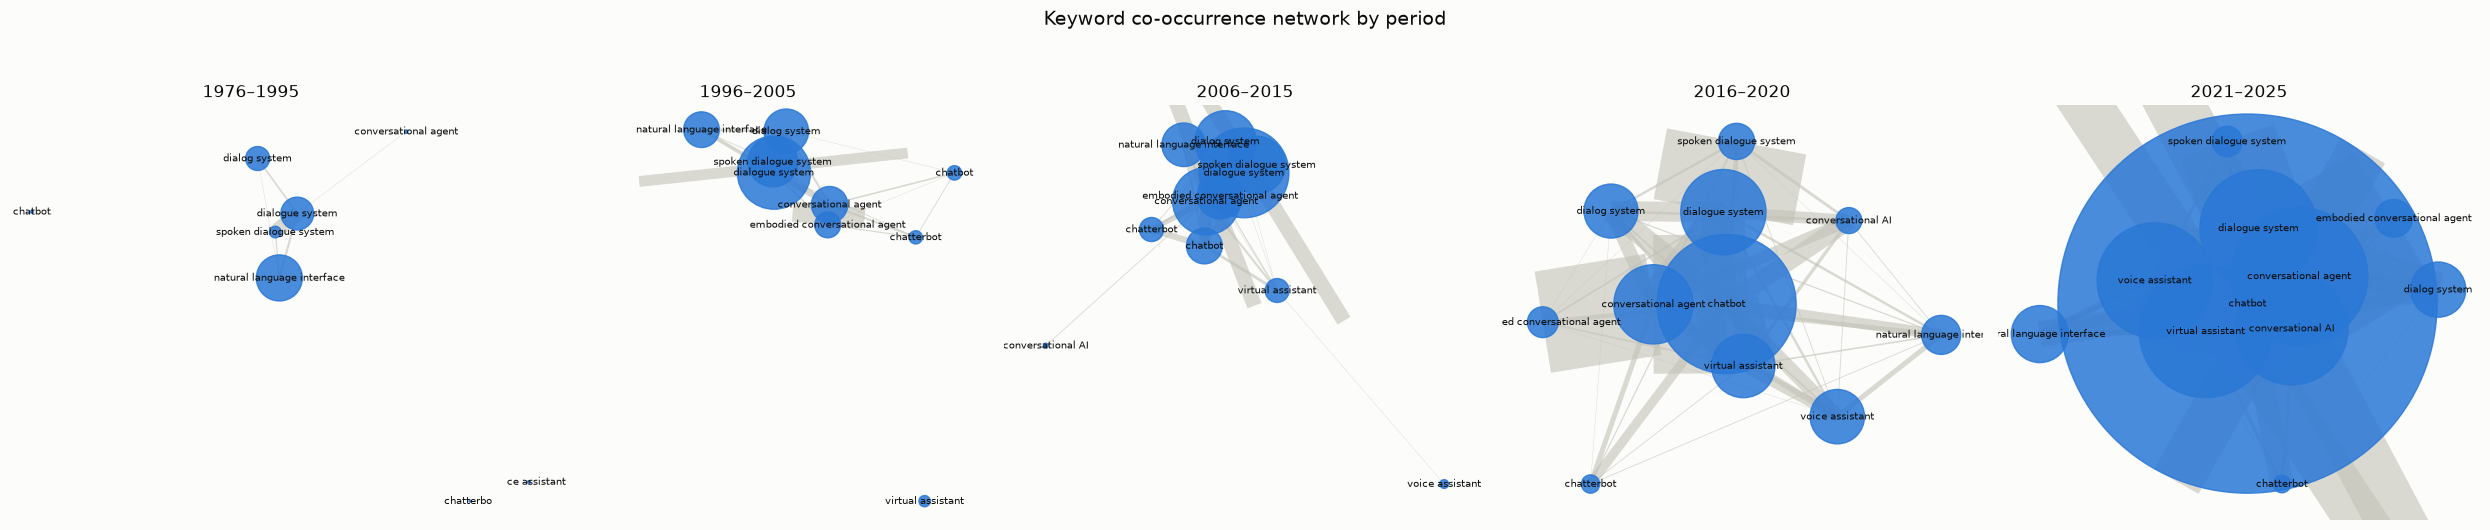

In [14]:
fig, axes = plt.subplots(1, len(periods), figsize=(5 * len(periods), 5), facecolor=CHART_SURFACE)

for ax, (start, end, label) in zip(axes, periods):
    ax.set_facecolor(CHART_SURFACE)
    G = period_graphs[label]

    if G.number_of_nodes() == 0:
        ax.set_title(f"{label}\n(no data)", fontsize=10, color=PRIMARY_INK)
        ax.axis("off")
        continue

    pos = nx.spring_layout(G, seed=42, k=0.8)

    node_sizes = [G.nodes[n]["weight"] * 2 for n in G.nodes]
    edge_widths = [G[u][v]["weight"] * 0.3 for u, v in G.edges]

    nx.draw_networkx_edges(G, pos, ax=ax, width=edge_widths, edge_color=BASELINE, alpha=0.6)
    nx.draw_networkx_nodes(G, pos, ax=ax, node_size=node_sizes, node_color=LINE_HUE, alpha=0.85)
    nx.draw_networkx_labels(G, pos, ax=ax, font_size=7, font_color=PRIMARY_INK)

    ax.set_title(label, fontsize=12, color=PRIMARY_INK)
    ax.axis("off")

fig.suptitle("Keyword co-occurrence network by period", fontsize=14, color=PRIMARY_INK, y=1.05)
fig.tight_layout()
fig.savefig("keyword_network_by_period.png", dpi=200, bbox_inches="tight", facecolor=CHART_SURFACE)
plt.show()

**Load pre-scored sentiment + emotions:** loads the sentiment/emotion scoring computed by the standalone script (run outside the notebook due to kernel instability with NRCLex), avoiding re-running that heavy computation in-kernel.

In [17]:
df_en = pd.read_parquet('../final_openalex_pipeline/data/processed/df_en_scored.parquet')
EMOTIONS = ["fear", "anticipation", "trust", "joy", "sadness", "anger"]

print(df_en.shape)
print(df_en[["sentiment_compound", "sentiment_label"] + EMOTIONS].describe())

(52448, 40)
       sentiment_compound          fear  anticipation         trust  \
count        52448.000000  52448.000000  52448.000000  52448.000000   
mean             0.723995      0.051820      0.097877      0.206522   
std              0.438734      0.045563      0.070878      0.095840   
min             -1.000000      0.000000      0.000000      0.000000   
25%              0.714000      0.016249      0.057692      0.147059   
50%              0.920100      0.045455      0.090909      0.200000   
75%              0.971600      0.078431      0.129032      0.255814   
max              1.000000      1.000000      1.000000      1.000000   

                joy       sadness         anger  
count  52448.000000  52448.000000  52448.000000  
mean       0.053412      0.032977      0.027047  
std        0.040227      0.038731      0.032857  
min        0.000000      0.000000      0.000000  
25%        0.025641      0.000000      0.000000  
50%        0.050000      0.024096      0.020000 

**Re-derive parsed keyword list on df_en:** the freshly-loaded df_en needs the same detected_terms_list parsing we did on the full corpus, since it's a separately loaded file.

In [19]:
df_en['detected_terms_list'] = df_en['detected_terms_in_title_abstract'].fillna('').apply(
    lambda s: [t.strip() for t in s.split(';') if t.strip()]
)
print(df_en['detected_terms_list'].head())

0                 [dialog system]
1                 [dialog system]
2    [natural language interface]
3               [dialogue system]
4    [natural language interface]
Name: detected_terms_list, dtype: object
